               Value
Date                
2020-01-01  0.529216
2020-01-02  0.318716
2020-01-03  0.683040
2020-01-04  1.236910
2020-01-05  1.277623


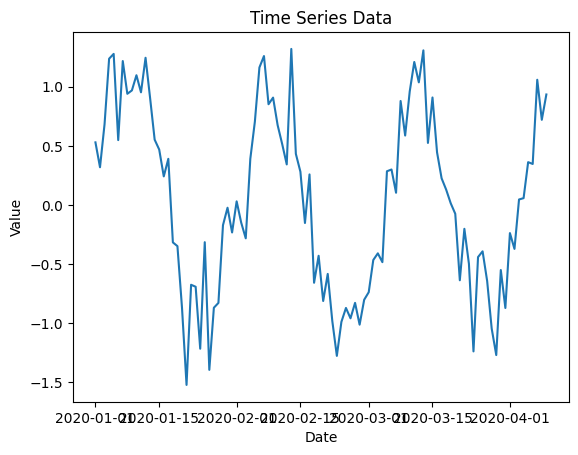

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 0.5723670107913122
MSE: 0.45409836114229823
RMSE: 0.6738682075467711


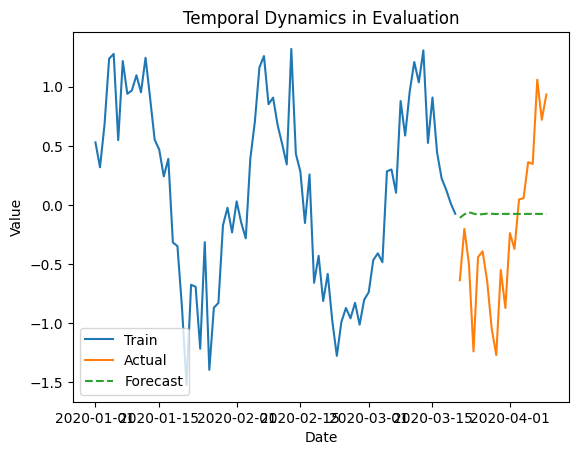

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_2694/1384500231.py:93: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = model_fit.forecast(steps=1)[0]
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: Value

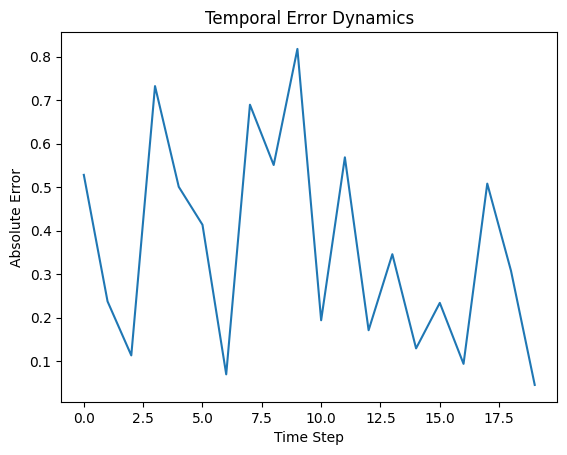

In [1]:
# ===============================
# 1. Install Required Libraries
# ===============================
!pip install numpy pandas matplotlib scikit-learn statsmodels

# ===============================
# 2. Import Libraries
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

# ===============================
# 3. Create Sample Time Series Data
# ===============================
# Simulating temporal data (like sales over time)

np.random.seed(0)

dates = pd.date_range(start="2020-01-01", periods=100)
data = np.sin(np.arange(100) / 5) + np.random.normal(0, 0.3, 100)

df = pd.DataFrame({"Date": dates, "Value": data})
df.set_index("Date", inplace=True)

print(df.head())

# ===============================
# 4. Plot Time Series
# ===============================
plt.figure()
plt.plot(df.index, df["Value"])
plt.title("Time Series Data")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

# ===============================
# 5. Train-Test Split
# ===============================
train_size = int(len(df) * 0.8)
train, test = df[:train_size], df[train_size:]

# ===============================
# 6. ARIMA Model (Temporal Modeling)
# ===============================
model = ARIMA(train["Value"], order=(2,1,2))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# ===============================
# 7. Evaluation Metrics (Temporal Dynamics)
# ===============================
mae = mean_absolute_error(test["Value"], forecast)
mse = mean_squared_error(test["Value"], forecast)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

# ===============================
# 8. Plot Predictions vs Actual
# ===============================
plt.figure()
plt.plot(train.index, train["Value"], label="Train")
plt.plot(test.index, test["Value"], label="Actual")
plt.plot(test.index, forecast, label="Forecast", linestyle="--")

plt.legend()
plt.title("Temporal Dynamics in Evaluation")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

# ===============================
# 9. Rolling Evaluation (Dynamic Performance)
# ===============================
errors = []

for i in range(len(test)):
    train_dynamic = df[:train_size + i]
    model = ARIMA(train_dynamic["Value"], order=(2,1,2))
    model_fit = model.fit()

    pred = model_fit.forecast(steps=1)[0]
    actual = test["Value"].iloc[i]

    error = abs(actual - pred)
    errors.append(error)

# Plot error over time
plt.figure()
plt.plot(errors)
plt.title("Temporal Error Dynamics")
plt.xlabel("Time Step")
plt.ylabel("Absolute Error")
plt.show()